# RNN for captions

In [1]:
import numpy as np
import pandas as pd

### Load split data

In [2]:
train_df = pd.read_csv(
    "data/train_df.csv",
    parse_dates=["publish_timestamp"]  # converts datestime string into datetime object
)
test_df = pd.read_csv(
    "data/test_df.csv",
    parse_dates=["publish_timestamp"]
)

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77574 entries, 0 to 77573
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   77574 non-null  int64         
 1   username                  77574 non-null  object        
 2   publish_timestamp         77574 non-null  datetime64[ns]
 3   has_location              77574 non-null  int64         
 4   is_carousel               77574 non-null  int64         
 5   num_images                77574 non-null  int64         
 6   is_sponsored              77574 non-null  int64         
 7   image_path                77574 non-null  object        
 8   caption                   77574 non-null  object        
 9   following                 77574 non-null  int64         
 10  follower_following_ratio  77574 non-null  float64       
 11  hour                      77574 non-null  int64         
 12  day               

# Set random seed

In [4]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    # Ensure deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

### Fill any missing captions

In [5]:
train_df["caption"] = train_df["caption"].fillna("")
test_df["caption"]  = test_df["caption"].fillna("")


# BERT

### Import and initialize tokenizer

In [6]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

c:\Users\sugar\.conda\envs\genaideepl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Sample tokenization

In [7]:
# Example for a single caption
caption = "This is an example post caption!"
encoded = tokenizer(
    caption,
    padding='max_length',   # pad all sequences to max_length
    truncation=True,        # truncate if longer than max_length
    max_length=20,          # choose based on caption lengths 
    return_tensors='pt'     # return PyTorch tensors
)

print(encoded)


{'input_ids': tensor([[ 101, 1188, 1110, 1126, 1859, 2112, 6707, 2116,  106,  102,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


input_ids:
* Each number is the ID of a token in BERT’s vocabulary.
* 101 → [CLS] token, added automatically at the start for classification tasks.
* 102 → [SEP] token, added automatically at the end.
* 0 → [PAD] token, added because your caption is shorter than max_length=20.
* Numbers like 1188, 1110, ... → the IDs of actual words/subwords from the caption.
* Shape: (1, 20) → batch size 1, sequence length 20.

token_type_ids:
* 0: all tokens belong to sentence A
* for single-sentence classification tasks, all values are 0.

attention_mask:
* 1: real tokens, 0: padding

### Tokenize train and test sets separately

Since BERT's vocab is fixed, we encode each set instead of fitting the tokenizer on train only.

In [8]:
train_encodings = tokenizer(
    train_df['caption'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=64,          # choose based on caption lengths (median 21, but max 400 words)
    return_tensors='pt'
)

test_encodings = tokenizer(
    test_df['caption'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=64,          # choose based on caption lengths (median 21, but max 400 words)
    return_tensors='pt'
)


In [9]:
y_train = train_df["engagement_label"].values

y_test = test_df["engagement_label"].values

### PyTorch dataset

In [10]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings  # a dict from tokenizer
        self.labels = labels

    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        # Return a dict with each item converted to tensor
        item = {key: val[idx].detach().clone() for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = TextDataset(train_encodings, y_train)
test_ds  = TextDataset(test_encodings, y_test)


### DataLoader

In [11]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

In [13]:
from torch.utils.data import DataLoader
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

### Class balancing

In [14]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([0.9816, 0.9949, 1.0245], device='cuda:0')


### BERT model

In [ ]:
from transformers import BertModel
import torch.nn as nn
from unsloth import FastLanguageModel

# Load pretrained model
# bert_model = BertModel.from_pretrained("bert-base-uncased")

# Load pretrained model with unsloth for faster inference
bert_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/bert-base-uncased", # Or another supported encoder
    max_seq_length = 128,
    load_in_4bit = True, # Use 4-bit to save massive VRAM
)

class CaptionBERT(nn.Module):
    def __init__(self, bert_model, hidden_dim=256, num_classes=3, dropout=0.5):
        super().__init__()
        self.bert = bert_model

        self.dropout = nn.Dropout(dropout)
        self.fc_hidden = nn.Linear(self.bert.config.hidden_size, hidden_dim) # self.bert.config.hidden_size is 768 for bert-base
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)     # output: last_hidden_state [batch_size, seq_len, hidden_size], pooler_output [batch_size, hidden_size] - a pooled embedding for the [CLS] token
        cls_emb = outputs.last_hidden_state[:,0,:]  # [CLS] token embedding. takes all examples and all features, first token ([CLS]). cls_emb is embedding representing the whole sentence
        x = self.dropout(cls_emb)
        x = self.fc_hidden(x)
        x = self.relu(x)
        x = self.dropout(x)
        out = self.fc_out(x) # raw logits
        return out

# if freeze_bert: # prevents BERT weights from being updated
#     for param in self.bert.parameters(): # for all trainable tensors in BERT
#         param.requires_grad = False      # don't compute gradients for tensor
# else:
#     for param in self.bert.parameters(): # freeze everythin first
#         param.requires_grad = False 
#     for layer in model.bert.encoder.layer[-2:]: # unfreeze top 2 BERT layers
#         for param in layer.parameters():
#             param.requires_grad = True
#     for param in model.fc_hidden.parameters(): # train classifier head
#         param.requires_grad = True
#     for param in model.fc_out.parameters():
#         param.requires_grad = True

# Hyperparameters
hidden_dim = 256 # original 128
learning_rate = 2e-5 # reduced learning rate from 0.001 to 0.00002

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CaptionBERT(bert_model).to(device)
# Baseline freeze
for param in model.bert.parameters(): # for all trainable tensors in BERT
        param.requires_grad = False

criterion = nn.CrossEntropyLoss(weight=class_weights)
# Set optimizer for frozen BERT
optimizer = torch.optim.Adam(
    list(model.fc_hidden.parameters()) + list(model.fc_out.parameters()),
    lr=learning_rate
)


In [16]:
print(model)

CaptionBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

### Train and test loop

In [17]:

# training loop
def train_epoch(loader):
    # Put model in training mode
    model.train()

    # Initialize accumulator for total loss
    total_loss = 0

    # Loops over batches in training set
    for batch in loader:
        # Detect if batch is a dict (BERT-style) or tuple (LSTM/MLP/CNN)
        if isinstance(batch, dict):
            # BERT-style
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # total_loss += loss.item()
            # correct += (logits.argmax(dim=1) == labels).sum().item()
            # total += labels.size(0)

        else:
            # Tuple-style: (X, y) for LSTM, MLP, CNN
            X, y = batch

            # Move x y to same device
            X, y = X.to(device), y.to(device)

            # Clear old gradients from previous batch
            optimizer.zero_grad()

            # Feeds batch into model, perform forward pass, output logits
            logits = model(X)
            # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            # Compute loss for this batch
            loss = criterion(logits, y)

            # Performs backpropagation: computes gradients of the loss with respect to each model parameter.
            loss.backward()

            # Updates model parameters using those gradients
            optimizer.step()

        # Adds the numeric loss value (converted from a tensor with .item()) to the total loss accumulator.
        total_loss += loss.item()

    # Average loss = total loss / number of batches
    avg_loss = total_loss / len(loader)
    
    return avg_loss




In [18]:
def test_epoch(loader):
    # Set model to evaluation mode. Disables dropout, freezes batchnorm stats
    model.eval()

    # Initialize accumulator for total loss
    total_loss = 0

    with torch.no_grad(): # Disables gradient tracking inside this block.
    # This saves memory and time, since we don’t need gradients for validation.
    # It also ensures the model’s weights won’t accidentally be updated.
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
                # total_loss += criterion(logits, labels).item()
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            total_loss += criterion(logits, y).item()

    # Compute average loss
    avg_loss = total_loss / len(loader)
    
    return avg_loss

In [19]:
from sklearn.metrics import confusion_matrix, f1_score

def evaluate_metrics(loader, model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)

                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Accuracy
    correct = sum(p == y for p, y in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return accuracy, cm, macro_f1


### Baseline

In [ ]:
results = []
best_row = None

for epoch in range(10):

    train_loss = train_epoch(train_loader)
    test_loss  = test_epoch(test_loader)

    # Metrics
    train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

    best_row = {
        "model": "Baseline BERT",
        "best_epoch": epoch + 1,
        "train_macro_f1": train_macro_f1,
        "train_acc": train_acc,
        "train_cm": train_cm,
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
        "test_cm": test_cm,
    }
    results.append(best_row)

    print(f"\nEpoch {epoch+1}")
    print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

    print("Train Confusion Matrix:")
    print(train_cm)

    print("Test Confusion Matrix:")
    print(test_cm)

df_baseline = pd.DataFrame(results)


Epoch 1
Train   | loss=1.1043, acc=0.362, macro-F1=0.360
Test    | loss=1.0943, acc=0.365, macro-F1=0.356
Train Confusion Matrix:
[[ 8464  8744  9136]
 [ 6968  8480 10543]
 [ 6246  7870 11123]]
Test Confusion Matrix:
[[1685 2057 2198]
 [1608 2205 2471]
 [1956 2573 3488]]

Epoch 2
Train   | loss=1.0988, acc=0.365, macro-F1=0.351
Test    | loss=1.0962, acc=0.340, macro-F1=0.328
Train Confusion Matrix:
[[ 9918 13078  3348]
 [ 8177 13567  4247]
 [ 7387 12985  4867]]
Test Confusion Matrix:
[[1969 3242  729]
 [1879 3484  921]
 [2304 4293 1420]]

Epoch 3
Train   | loss=1.0972, acc=0.369, macro-F1=0.354
Test    | loss=1.0971, acc=0.340, macro-F1=0.330
Train Confusion Matrix:
[[10694 12521  3129]
 [ 8685 13301  4005]
 [ 7876 12695  4668]]
Test Confusion Matrix:
[[2175 3047  718]
 [2065 3327  892]
 [2456 4186 1375]]

Epoch 4
Train   | loss=1.0961, acc=0.375, macro-F1=0.373
Test    | loss=1.0949, acc=0.359, macro-F1=0.358
Train Confusion Matrix:
[[11947  8244  6153]
 [ 9839  8637  7515]
 [ 8906 

In [ ]:
# Best model by test macro F1
best_row = df_baseline.loc[df_baseline["test_macro_f1"].idxmax()]
print(best_row)

model                                               Baseline BERT
best_epoch                                                     10
train_macro_f1                                           0.436741
train_acc                                                 0.46295
train_cm          [[338, 45, 79], [279, 90, 127], [187, 73, 253]]
test_macro_f1                                            0.456693
test_acc                                                 0.492021
test_cm               [[110, 17, 20], [60, 29, 25], [50, 19, 46]]
Name: 9, dtype: object


In [ ]:
# Rank models by test macro F1
df_baseline.sort_values("test_macro_f1", ascending=False).head(5)

,model,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm
9,Baseline BERT,10,0.436741,0.462950,"[[338, 45, 79], [279, 90, 127], [187, 73, 253]]",0.456693,0.492021,"[[110, 17, 20], [60, 29, 25], [50, 19, 46]]"
0,Baseline BERT,1,0.432263,0.462950,"[[337, 44, 81], [280, 79, 137], [188, 60, 265]]",0.448760,0.489362,"[[111, 16, 20], [59, 25, 30], [49, 18, 48]]"
4,Baseline BERT,5,0.422725,0.450034,"[[333, 52, 77], [285, 82, 129], [189, 77, 247]]",0.447529,0.486702,"[[111, 18, 18], [57, 27, 30], [50, 20, 45]]"
2,Baseline BERT,3,0.439777,0.460231,"[[311, 68, 83], [257, 100, 139], [176, 71, 266]]",0.444937,0.470745,"[[99, 27, 21], [53, 31, 30], [47, 21, 47]]"
3,Baseline BERT,4,0.437534,0.456152,"[[315, 68, 79], [258, 105, 133], [178, 84, 251]]",0.440963,0.468085,"[[100, 27, 20], [53, 31, 30], [47, 23, 45]]"


# Performance Tuning

In [ ]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([1.0613, 0.9886, 0.9558], device='cuda:0')


### Set fixed parameters

In [ ]:
# fixed parameters
y_train = train_df["engagement_label"].values
y_test = test_df["engagement_label"].values
batch_size = 32

device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss(weight=class_weights)

hidden_dim = 256 # for classification head only (768 to hidden dim 256 to 3)

### estimate time taken

In [ ]:
# import time
# max_len = 128
# from torch.utils.data import DataLoader
# # Tokenize
# train_encodings = tokenizer(
#     train_df['caption'].tolist(),
#     padding='max_length',
#     truncation=True,
#     max_length=max_len,          # choose based on caption lengths (median 21, but max 400 words)
#     return_tensors='pt'
# )

# test_encodings = tokenizer(
#     test_df['caption'].tolist(),
#     padding='max_length',
#     truncation=True,
#     max_length=max_len,          # choose based on caption lengths (median 21, but max 400 words)
#     return_tensors='pt'
# )

# # Create dataset
# train_ds = TextDataset(train_encodings, y_train)
# test_ds  = TextDataset(test_encodings, y_test)

# # Load data
# train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
# test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# model = CaptionBERT(bert_model, hidden_dim=hidden_dim, dropout=0.3).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# start = time.time()

# for epoch in range(3):
#     train_epoch(train_loader)
#     test_epoch(test_loader)
#     evaluate_metrics(train_loader, model)
#     evaluate_metrics(test_loader, model)

# end = time.time()

# seconds_per_epoch = (end - start) / 3
# print(f"≈ {seconds_per_epoch:.2f} seconds per epoch")


In [ ]:
# num_runs = (
#     len([True, False]) *
#     len([64, 128]) *
#     len([0.3, 0.5]) *
#     len([1e-3, 5e-4])
# )

# print("Total runs:", num_runs)

# estimated_time = seconds_per_epoch * 20 * num_runs
# print(f"Estimated total time: {estimated_time/60:.1f} minutes")



In [ ]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

### Tuning loop

In [ ]:
import copy
import matplotlib.pyplot as plt
import gc

results = []
best_state = None
global_best_f1 = 0


patience = 5 # stop if no improvement after 5 epochs

# Initialize plot
plt.figure(figsize=(8,5))

for max_len in [64, 128]:
    # Tokenize
    train_encodings = tokenizer(
        train_df['caption'].tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,          # choose based on caption lengths (median 21, but max 400 words)
        return_tensors='pt'
    )

    test_encodings = tokenizer(
        test_df['caption'].tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,          # choose based on caption lengths (median 21, but max 400 words)
        return_tensors='pt'
    )

    # Create dataset
    train_ds = TextDataset(train_encodings, y_train)
    test_ds  = TextDataset(test_encodings, y_test)

    # Load data
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    for freeze_bert in [True, False]:
        if freeze_bert:
            lr_grid = [1e-3, 5e-4]
        else:
            lr_grid = [2e-5, 5e-5]

        for dropout in [0.3, 0.5]:
            for learning_rate in lr_grid:
            
                print("\n=====\nNew tuning parameters: ")
                print(f"freeze_bert: {freeze_bert}")
                print(f"dropout: {dropout}")
                print(f"learning_rate: {learning_rate}\n")
                print(f"max_len: {max_len}\n")

                # Set parameters for model and optimizer
                # bert_model = BertModel.from_pretrained("bert-base-uncased")
                bert_model, tokenizer = FastLanguageModel.from_pretrained(
                    model_name = "unsloth/bert-base-uncased", # Or another supported encoder
                    max_seq_length = 128,
                    load_in_4bit = True, # Use 4-bit to save massive VRAM
                )
                model = CaptionBERT(bert_model, hidden_dim=hidden_dim, dropout=dropout).to(device)

                print("Trainable params:",
                    sum(p.requires_grad for p in model.parameters()))


                if freeze_bert: # prevents BERT weights from being updated
                    for param in model.bert.parameters(): # for all trainable tensors in BERT
                        param.requires_grad = False      # don't compute gradients for tensor
                    
                    # Set optimizer for frozen BERT
                    optimizer = torch.optim.Adam(
                        list(model.fc_hidden.parameters()) + list(model.fc_out.parameters()),
                        lr=learning_rate
                    )

                else:
                    for param in model.bert.parameters(): # freeze everything first
                        param.requires_grad = False 
                    for layer in model.bert.encoder.layer[-2:]: # unfreeze top 2 BERT layers
                        for param in layer.parameters():
                            param.requires_grad = True
                    for param in model.fc_hidden.parameters(): # train classifier head
                        param.requires_grad = True
                    for param in model.fc_out.parameters():
                        param.requires_grad = True
                    # Set optimizer from partially unfrozen BERT
                    optimizer = torch.optim.AdamW([
                        {"params": model.bert.encoder.layer[-2:].parameters(), "lr": 2e-5},
                        {"params": model.fc_hidden.parameters(), "lr": learning_rate},
                        {"params": model.fc_out.parameters(), "lr": learning_rate},
                    ])

                print(model)

                # Re-initialize metrics before epochs
                best_test_f1 = 0
                best_row = None
                no_improve_epochs = 0
                train_macro_f1_list = []
                test_macro_f1_list = []

                for epoch in range(50):
                    train_loss = train_epoch(train_loader)
                    test_loss  = test_epoch(test_loader)

                    # Metrics
                    if (epoch + 1) % 10 == 0 or epoch == 0: # evaluate training model only every 10 epochs to save processing time
                        train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
                    else:
                        train_acc = train_macro_f1 = None
                        train_cm = None
                    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

                    # Keep metrics for plotting
                    train_macro_f1_list.append(train_macro_f1)
                    test_macro_f1_list.append(test_macro_f1)

                    if test_macro_f1 > best_test_f1:
                        # Update best F1
                        best_test_f1 = test_macro_f1
                        # Save model metrics and parameters for plot/chart
                        best_row = {
                            "model": "BERT",
                            "freeze_bert": freeze_bert,
                            "dropout": dropout,
                            "learning_rate": learning_rate,
                            "max_len": max_len,
                            "best_epoch": epoch + 1,
                            "train_macro_f1": train_macro_f1,
                            "train_acc": train_acc,
                            "train_cm": train_cm,
                            "test_macro_f1": test_macro_f1,
                            "test_acc": test_acc,
                            "test_cm": test_cm,

                            "train_f1_history": train_macro_f1_list.copy(),
                            "test_f1_history": test_macro_f1_list.copy(),
                        }
                        no_improve_epochs = 0  # reset patience counter
                        if test_macro_f1 > global_best_f1:
                            # Update global best F1
                            global_best_f1 = test_macro_f1
                            # Save model state for loading later using load_state_dict
                            best_state = copy.deepcopy(model.state_dict())
                    else:
                        no_improve_epochs += 1

                    

                    print(f"\nEpoch {epoch+1}")
                    if train_macro_f1 is not None:
                        print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
                    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")
                    if train_cm is not None:
                        print("Train Confusion Matrix:")
                        print(train_cm)

                    print("Test Confusion Matrix:")
                    print(test_cm)

                    if no_improve_epochs >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break
                            
                # Keep only the best epoch of the parameter configuration
                results.append(best_row)

                # After the epoch loop finishes and you save the results
                del model
                del bert_model
                if torch.cuda.is_available():
                    torch.cuda.empty_cache() 
                gc.collect()

            
df_results = pd.DataFrame(results)
torch.save(best_state, "best_bert_model.pt")



=====
New tuning parameters: 
freeze_bert: True
dropout: 0.3
learning_rate: 0.001

max_len: 64

Trainable params: 203
CaptionBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Lin

<Figure size 800x500 with 0 Axes>

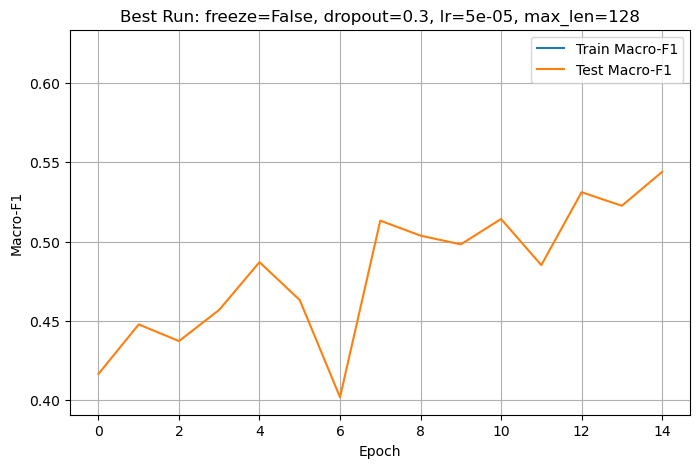

In [ ]:
best_run = max(results, key=lambda x: x["test_macro_f1"])

plt.figure(figsize=(8,5))
plt.plot(best_run["train_f1_history"], label="Train Macro-F1")
plt.plot(best_run["test_f1_history"], label="Test Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title(
    f"Best Run: freeze={best_run['freeze_bert']}, "
    f"dropout={best_run['dropout']}, "
    f"lr={best_run['learning_rate']}, "
    f"max_len={best_run['max_len']}"
)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Best model by test macro F1
best_row = df_results.loc[df_results["test_macro_f1"].idxmax()]
print(best_row)


model                                                            BERT
freeze_bert                                                     False
dropout                                                           0.3
learning_rate                                                 0.00005
max_len                                                           128
best_epoch                                                         15
train_macro_f1                                                    NaN
train_acc                                                         NaN
train_cm                                                         None
test_macro_f1                                                0.543958
test_acc                                                      0.56117
test_cm                   [[107, 23, 17], [44, 43, 27], [42, 12, 61]]
train_f1_history    [0.44609182518924834, None, None, None, None, ...
test_f1_history     [0.41661764738574947, 0.44782336600943423, 0.4...
Name: 13, dtype: obj

In [ ]:
# Rank models by test macro F1
df_results.sort_values("test_macro_f1", ascending=False).head(5)


,model,freeze_bert,dropout,learning_rate,max_len,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
13,BERT,False,0.3,0.00005,128,15,NaN,NaN,None,0.543958,0.561170,"[[107, 23, 17], [44, 43, 27], [42, 12, 61]]","[0.44609182518924834, None, None, None, None, ...","[0.41661764738574947, 0.44782336600943423, 0.4..."
15,BERT,False,0.5,0.00005,128,9,NaN,NaN,None,0.537619,0.547872,"[[96, 25, 26], [36, 50, 28], [31, 24, 60]]","[0.3711235349935505, None, None, None, None, N...","[0.3612601285868613, 0.413030873142134, 0.4907..."
14,BERT,False,0.5,0.00002,128,20,0.716516,0.726037,"[[373, 30, 59], [84, 239, 173], [23, 34, 456]]",0.525614,0.537234,"[[80, 29, 38], [28, 41, 45], [17, 17, 81]]","[0.43873634210345397, None, None, None, None, ...","[0.3850157018104225, 0.46118819937717576, 0.46..."
12,BERT,False,0.3,0.00002,128,7,NaN,NaN,None,0.516154,0.521277,"[[78, 32, 37], [32, 48, 34], [23, 22, 70]]","[0.36949943431583315, None, None, None, None, ...","[0.3852505834133204, 0.3949287934103733, 0.458..."
10,BERT,True,0.5,0.00100,128,10,0.503452,0.525493,"[[290, 47, 125], [187, 125, 184], [109, 46, 358]]",0.512597,0.531915,"[[93, 12, 42], [43, 34, 37], [33, 9, 73]]","[0.38089119855992476, None, None, None, None, ...","[0.3726235213274278, 0.40685032275177857, 0.48..."


In [ ]:
# Compare freeze_bert effects
df_results.groupby("freeze_bert")["test_macro_f1"].mean()

freeze_bert
False    0.514475
True     0.493013
Name: test_macro_f1, dtype: float64

In [ ]:
# Compare dropout effects
df_results.groupby("dropout")["test_macro_f1"].mean()


dropout
0.3    0.506065
0.5    0.501422
Name: test_macro_f1, dtype: float64

In [ ]:
# Compare learning_rate effects
df_results.groupby("learning_rate")["test_macro_f1"].mean()

learning_rate
0.00002    0.512012
0.00005    0.516937
0.00050    0.494039
0.00100    0.491987
Name: test_macro_f1, dtype: float64

In [ ]:
# Compare max_len effects
df_results.groupby("max_len")["test_macro_f1"].mean()

max_len
64     0.487998
128    0.519489
Name: test_macro_f1, dtype: float64

In [ ]:
# Best epoch per configuration
df_results.loc[
    df_results.groupby(
        ["freeze_bert", "dropout", "learning_rate", "max_len"]
    )["test_macro_f1"].idxmax()
]


,model,freeze_bert,dropout,learning_rate,max_len,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
4,BERT,False,0.3,0.00002,64,9,NaN,NaN,None,0.511335,0.513298,"[[79, 45, 23], [32, 57, 25], [30, 28, 57]]","[0.43681352014653013, None, None, None, None, ...","[0.44200599807422725, 0.4310079485179335, 0.45..."
12,BERT,False,0.3,0.00002,128,7,NaN,NaN,None,0.516154,0.521277,"[[78, 32, 37], [32, 48, 34], [23, 22, 70]]","[0.36949943431583315, None, None, None, None, ...","[0.3852505834133204, 0.3949287934103733, 0.458..."
5,BERT,False,0.3,0.00005,64,4,NaN,NaN,None,0.506016,0.521277,"[[99, 26, 22], [40, 47, 27], [40, 25, 50]]","[0.25647406735070083, None, None, None]","[0.20848426057854472, 0.40774419597213635, 0.4..."
13,BERT,False,0.3,0.00005,128,15,NaN,NaN,None,0.543958,0.561170,"[[107, 23, 17], [44, 43, 27], [42, 12, 61]]","[0.44609182518924834, None, None, None, None, ...","[0.41661764738574947, 0.44782336600943423, 0.4..."
6,BERT,False,0.5,0.00002,64,11,NaN,NaN,None,0.494946,0.513298,"[[100, 28, 19], [47, 39, 28], [39, 22, 54]]","[0.38210199835662717, None, None, None, None, ...","[0.40565848475977845, 0.4193644998755715, 0.45..."
14,BERT,False,0.5,0.00002,128,20,0.716516,0.726037,"[[373, 30, 59], [84, 239, 173], [23, 34, 456]]",0.525614,0.537234,"[[80, 29, 38], [28, 41, 45], [17, 17, 81]]","[0.43873634210345397, None, None, None, None, ...","[0.3850157018104225, 0.46118819937717576, 0.46..."
7,BERT,False,0.5,0.00005,64,8,NaN,NaN,None,0.480156,0.515957,"[[100, 15, 32], [45, 24, 45], [39, 6, 70]]","[0.4056110848246304, None, None, None, None, N...","[0.3942235390059538, 0.36712545870584323, 0.39..."
15,BERT,False,0.5,0.00005,128,9,NaN,NaN,None,0.537619,0.547872,"[[96, 25, 26], [36, 50, 28], [31, 24, 60]]","[0.3711235349935505, None, None, None, None, N...","[0.3612601285868613, 0.413030873142134, 0.4907..."
1,BERT,True,0.3,0.00050,64,7,NaN,NaN,None,0.477522,0.523936,"[[126, 9, 12], [68, 28, 18], [65, 7, 43]]","[0.41536158196443346, None, None, None, None, ...","[0.435, 0.4601530918081614, 0.4763949652025758..."
9,BERT,True,0.3,0.00050,128,8,NaN,NaN,None,0.504290,0.531915,"[[100, 9, 38], [48, 29, 37], [40, 4, 71]]","[0.4157133324384213, None, None, None, None, N...","[0.40815400570391497, 0.4391461949280379, 0.47..."


# Clear memory

In [ ]:
del model
torch.cuda.empty_cache()


NameError: name 'model' is not defined